# Análisis de Absentismo Laboral - RHHH

### Preguntas de negocio

> ¿Qué variables personales y laborales están más asociadas a niveles elevados de absentismo?  

> ¿podríamos ajustar nuestras políticas internas para abordar proactivamente estos perfiles de riesgo y reducir las ausencias?



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from datetime import datetime, date, time, timedelta
from getpass import getpass
from sqlalchemy import create_engine, inspect

### Utilizamos una REGRESION BINOMIAL NEGATIVA 

In [5]:
import numpy as np
import statsmodels.formula.api as smf

# ==============================
# 1. Base para el modelo
# ==============================

df_RRHH_07072026 = pd.read_csv(r"C:\Users\Usuario\OneDrive\Documentos\IT ACADEMY\SIMULADOR\ProjecteData\Equip_33\Data\DatasetClean_2026-07-06.csv")

df_modelo = (
    df_RRHH_07072026
    .groupby("ID_Employee")
    .agg(
        Total_Horas_Absentismo=("Absenteeism_Hours", "sum"),
        Age=("Age", "first"),
        Education=("Education", "first"),
        Son=("Son", "first"),
        Social_Drinker=("Social_Drinker", "first"),
        Social_Smoker=("Social_Smoker", "first"),
        Pet=("Pet", "first"),
        Body_Mass_Index=("Body_Mass_Index", "first"),
        Transportation_Expense=("Transportation_Expense", "mean"),
        Distance_Residence_Work=("Distance_Residence_Work", "first"),
        Service_Time=("Service_Time", "first"),
        Work_load_Average_Day=("Work_load_Average_Day", "mean"),
        Hit_Target=("Hit_Target", "mean"),
        Disciplinary_Failure=("Disciplinary_Failure", "max")
    )
    .reset_index()
)

# ==============================
# 2. Modelo Binomial Negativo
# ==============================

formula = """
Total_Horas_Absentismo ~
Age +
C(Education) +
Son +
C(Social_Drinker) +
C(Social_Smoker) +
Pet +
Body_Mass_Index +
Transportation_Expense +
Distance_Residence_Work +
Service_Time +
Work_load_Average_Day +
Hit_Target +
C(Disciplinary_Failure)
"""

modelo_nb = smf.negativebinomial(
    formula=formula,
    data=df_modelo
).fit(disp=False, maxiter=1000)

print(modelo_nb.summary())

                       NegativeBinomial Regression Results                        
Dep. Variable:     Total_Horas_Absentismo   No. Observations:                  136
Model:                   NegativeBinomial   Df Residuals:                      120
Method:                               MLE   Df Model:                           15
Date:                    Wed, 08 Jul 2026   Pseudo R-squ.:                 0.03780
Time:                            14:10:52   Log-Likelihood:                -563.40
converged:                           True   LL-Null:                       -585.53
Covariance Type:                nonrobust   LLR p-value:                 0.0001000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        8.9543      8.771      1.021      0.307      -8.236      26.145
C(Education)[T.2]                0.0887      

c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


- ### Segmentamos por infulencia 


In [7]:


# ==============================
# Tabla de importancia del modelo
# ==============================

resultados = pd.DataFrame({
    "Variable": modelo_nb.params.index,
    "Coeficiente": modelo_nb.params.values,
    "P_Value": modelo_nb.pvalues.values
})

# Quitamos intercepto y alpha
resultados = resultados[
    ~resultados["Variable"].isin(["Intercept", "alpha"])
].copy()

# IRR y efecto porcentual
resultados["IRR"] = np.exp(resultados["Coeficiente"])
resultados["Efecto_%"] = (resultados["IRR"] - 1) * 100

# Medida de importancia estadística
resultados["Importancia"] = abs(resultados["Efecto_%"]) * (-np.log10(resultados["P_Value"]))

# Limpiar nombres para el gráfico
resultados["Variable_Limpia"] = (
    resultados["Variable"]
    .str.replace("C(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("[T.", " = ", regex=False)
    .str.replace("]", "", regex=False)
)

# Más importantes
top_importantes = resultados.sort_values("Importancia", ascending=False).head(5)

# Menos importantes
menos_importantes = resultados.sort_values("Importancia", ascending=True).head(5)

- Variables mas influyentes

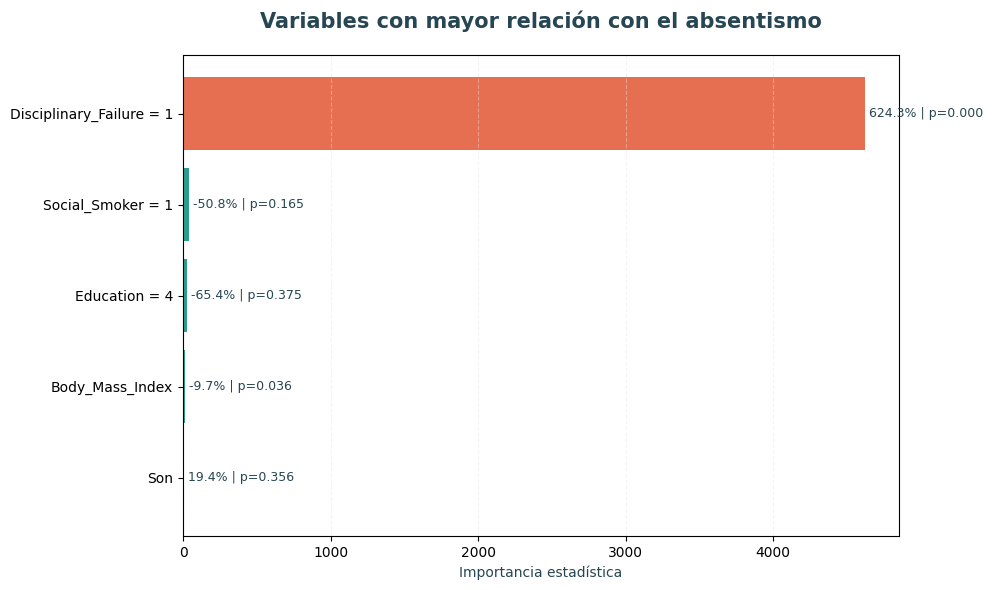

In [8]:
color_aumenta = "#E76F51"
color_reduce = "#2A9D8F"
color_texto = "#264653"
color_fondo = "#FFFFFF"
color_grid = "#E5E4E4"

top_importantes = top_importantes.sort_values("Importancia")

colores_top = [
    color_aumenta if efecto > 0 else color_reduce
    for efecto in top_importantes["Efecto_%"]
]

plt.figure(figsize=(10, 6))
plt.gcf().set_facecolor(color_fondo)

bars = plt.barh(
    top_importantes["Variable_Limpia"],
    top_importantes["Importancia"],
    color=colores_top
)

plt.title(
    "Variables con mayor relación con el absentismo",
    fontsize=15,
    fontweight="bold",
    color=color_texto,
    pad=20
)

plt.xlabel("Importancia estadística", color=color_texto)
plt.grid(axis="x", linestyle="--", alpha=0.4, color=color_grid)

for bar, efecto, pval in zip(
    bars,
    top_importantes["Efecto_%"],
    top_importantes["P_Value"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {efecto:.1f}% | p={pval:.3f}",
        va="center",
        fontsize=9,
        color=color_texto
    )

plt.tight_layout()
plt.show()

- Vriables menos influyentes 

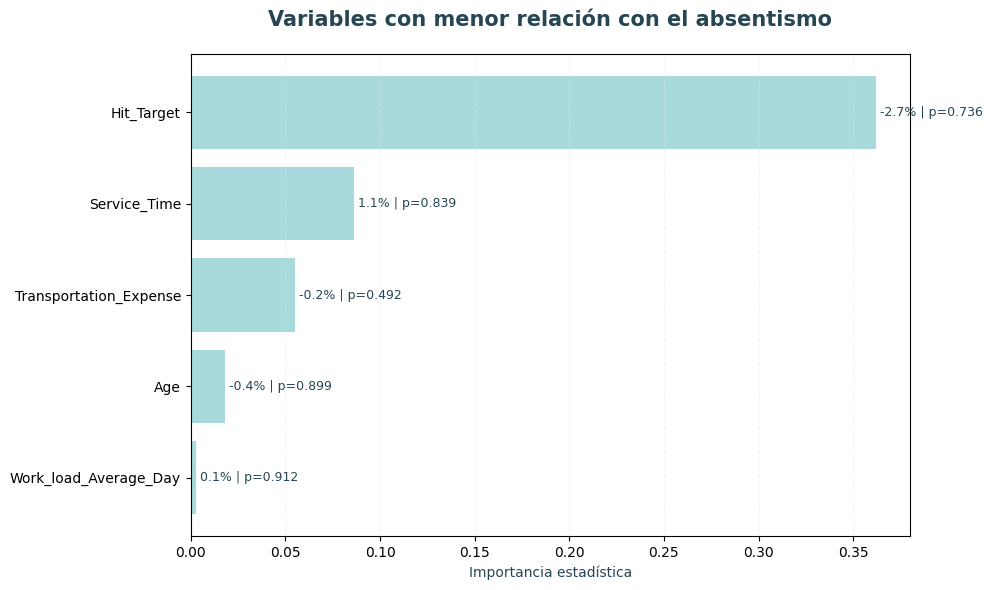

In [9]:
menos_importantes = menos_importantes.sort_values("Importancia")

plt.figure(figsize=(10, 6))
plt.gcf().set_facecolor(color_fondo)

bars = plt.barh(
    menos_importantes["Variable_Limpia"],
    menos_importantes["Importancia"],
    color="#A8DADC"
)

plt.title(
    "Variables con menor relación con el absentismo",
    fontsize=15,
    fontweight="bold",
    color=color_texto,
    pad=20
)

plt.xlabel("Importancia estadística", color=color_texto)
plt.grid(axis="x", linestyle="--", alpha=0.4, color=color_grid)

for bar, efecto, pval in zip(
    bars,
    menos_importantes["Efecto_%"],
    menos_importantes["P_Value"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {efecto:.1f}% | p={pval:.3f}",
        va="center",
        fontsize=9,
        color=color_texto
    )

plt.tight_layout()
plt.show()